In [3]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score, f1_score

from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r"Telco-Customer-Churn.csv")
pro_df = df.copy()
print("----------------------------------------------------")
print("\nDataset Info:")
print(pro_df.info())

----------------------------------------------------

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7037 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7037 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7038 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          704

In [5]:
pro_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,-3895.00,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,151.65,Yes


In [6]:
pro_df.shape

(7043, 21)

In [7]:
# ==========================================
# Initial Missing Values Check
# ==========================================
print("\nInitial Missing values (before any processing):")
print(pro_df.isnull().sum())

# ==========================================
# Remove Duplicates
# ==========================================
before = pro_df.shape[0]
pro_df = pro_df.drop_duplicates().copy()
after = pro_df.shape[0]

print(f"\nRows before removing duplicates: {before}")
print(f"Rows after removing duplicates: {after}")
#=========================
# Type correction
#==========================
# Convert to string first (to handle mixed values safely)
pro_df['TotalCharges'] = pro_df['TotalCharges'].astype(str)


# Remove spaces and any non-numeric characters except dot
pro_df['TotalCharges'] = pro_df['TotalCharges'].str.strip()
pro_df['TotalCharges'] = pro_df['TotalCharges'].str.replace(r'[^0-9.]', '', regex=True)

# Convert to numeric
pro_df['TotalCharges'] = pd.to_numeric(pro_df['TotalCharges'], errors='coerce')

print("\nMissing values in  TotalCharges:")
print(pro_df['TotalCharges'].isnull().sum())

# ==========================================
# Handle Missing Values for Entire Dataset
# ==========================================

# Separate columns by type
num_cols = pro_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = pro_df.select_dtypes(include=['object']).columns

# ---------- Numerical Columns ----------
for col in num_cols:
    if pro_df[col].isnull().sum() > 0:
        median_value = pro_df[col].median()
        pro_df[col] = pro_df[col].fillna(median_value)
        print(f"{col} → filled with median")

# ---------- Categorical Columns ----------
for col in cat_cols:
    if pro_df[col].isnull().sum() > 0:
        pro_df[col] = pro_df[col].fillna("Unknown")
        print(f"{col} → filled with 'Unknown'")

# Final check
print("\nMissing values after full cleaning:")
print(pro_df.isnull().sum())

# ==========================================
# Fix Inconsistent Data
# ==========================================

# Convert SeniorCitizen safely
if pro_df['SeniorCitizen'].dtype != 'object':
    pro_df['SeniorCitizen'] = pro_df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Clean text columns
for col in pro_df.select_dtypes(include='object').columns:
    pro_df[col] = pro_df[col].str.strip()

print("\nText data cleaned successfully")

# ==========================================
# Pivot Tables (Basic Analysis)
# ==========================================

# Average Monthly Charges by Churn
pivot_table = pd.pivot_table(
    pro_df,
    values='MonthlyCharges',
    index='Churn',
    aggfunc='mean'
)

print("\nPivot Table 1:")
print(pivot_table)

# Customer count by Contract type and Churn
pivot_table2 = pd.pivot_table(
    pro_df,
    values='customerID',
    index='Contract',
    columns='Churn',
    aggfunc='count'
)

print("\nPivot Table 2:")
print(pivot_table2)


Initial Missing values (before any processing):
customerID           0
gender               0
SeniorCitizen        0
Partner              6
Dependents           0
tenure               0
PhoneService         6
MultipleLines        0
InternetService      5
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       7
TotalCharges        11
Churn                0
dtype: int64

Rows before removing duplicates: 7043
Rows after removing duplicates: 7043

Missing values in  TotalCharges:
11
MonthlyCharges → filled with median
TotalCharges → filled with median
Partner → filled with 'Unknown'
PhoneService → filled with 'Unknown'
InternetService → filled with 'Unknown'

Missing values after full cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure          

In [8]:
# ==========================================
# FEATURE EXTRACTION
# ==========================================

# 1. Average Monthly Spend
# (بيوضح متوسط صرف العميل في الشهر عبر مدة اشتراكه)
pro_df['AvgMonthlySpend'] = pro_df['TotalCharges'] / (pro_df['tenure'] + 1)


# 2. Services Count
# (عدد الخدمات اللي العميل مشترك فيها → يدل على مدى ارتباطه بالشركة)

services = [
    'PhoneService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

pro_df['ServicesCount'] = (pro_df[services] == 'Yes').sum(axis=1)


# 3. Tenure Group
# (تحويل مدة الاشتراك من رقم لمستوى سلوكي أسهل في التحليل)

pro_df['TenureGroup'] = pd.cut(
    pro_df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Medium', 'Long', 'Very Long']
)


# 4. High Value Customer
# (هل العميل بيصرف أعلى من المتوسط ولا لا)

threshold = pro_df['MonthlyCharges'].median()
pro_df['HighValue'] = (pro_df['MonthlyCharges'] > threshold).astype(int)


# 5. Long Contract Indicator
# (هل العميل عنده عقد طويل = استقرار أعلى)

pro_df['IsLongContract'] = pro_df['Contract'].isin(['One year', 'Two year']).astype(int)


# 6. Risk Score
# (مؤشر بسيط لاحتمال إن العميل يسيب الشركة)

pro_df['RiskScore'] = (
    (pro_df['Contract'] == 'Month-to-month').astype(int) +
    (pro_df['MonthlyCharges'] > pro_df['MonthlyCharges'].median()).astype(int) +
    (pro_df['tenure'] < 12).astype(int)
)


# ==========================================
# CHECK NEW FEATURES
# ==========================================
print("New Features Added:")
print(pro_df[['AvgMonthlySpend','ServicesCount','TenureGroup',
              'HighValue','IsLongContract','RiskScore']].head())


New Features Added:
   AvgMonthlySpend  ServicesCount TenureGroup  HighValue  IsLongContract  \
0        14.925000              1         New          0               0   
1       111.285714              3        Long          0               1   
2        36.050000              3         New          0               0   
3        40.016304              3        Long          0               1   
4        50.550000              1         New          0               0   

   RiskScore  
0          2  
1          0  
2          2  
3          0  
4          2  


In [9]:
df_fs = pro_df.copy()

df_fs['Churn'] = df_fs['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
# ==========================================
# FEATURE SELECTION - 3 METHODS
# ==========================================



# ==========================================
# 0. TARGET ENCODING
# ==========================================
pro_df['Churn'] = pro_df['Churn'].map({'Yes': 1, 'No': 0})


# ==========================================
# 1. METHOD 1: CORRELATION (FILTER)
# ==========================================
print("\n================ CORRELATION ================")

print("\nCORRELATION")

num_df = df_fs.select_dtypes(include=['int64','float64'])

corr = num_df.corr()['Churn'].sort_values(ascending=False)
print(corr)


# ==========================================
# 2. METHOD 2: CHI-SQUARE (FIXED)
# ==========================================


print("\n================ CHI-SQUARE ================")

chi_df = df_fs.copy()

for col in chi_df.columns:
    if chi_df[col].dtype == 'object' or str(chi_df[col].dtype) == 'category':
        chi_df[col] = chi_df[col].astype(str)

cat_cols = chi_df.select_dtypes(include=['object']).columns

le = LabelEncoder()

for col in cat_cols:
    chi_df[col] = le.fit_transform(chi_df[col])


X_chi = chi_df.drop(columns=['Churn', 'customerID'], errors='ignore')
y_chi = chi_df['Churn']

X_chi = X_chi.astype(float)

X_chi = X_chi.clip(lower=0)

chi_scores, _ = chi2(X_chi, y_chi)

chi_result = pd.Series(chi_scores, index=X_chi.columns)
chi_result = chi_result.sort_values(ascending=False)

print(chi_result)

# ==========================================
# 3. METHOD 3: RANDOM FOREST IMPORTANCE
# ==========================================
print("\n================ RANDOM FOREST ================")
from sklearn.ensemble import RandomForestClassifier

print("\nRANDOM FOREST")

X = df_fs.drop(columns=['Churn','customerID'], errors='ignore')
y = df_fs['Churn']

X_encoded = pd.get_dummies(X, drop_first=True)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_encoded, y)

rf_importance = pd.Series(rf.feature_importances_, index=X_encoded.columns)
print(rf_importance.sort_values(ascending=False))

# ==========================================
# 4. TOP FEATURES COMPARISON
# ==========================================
print("\n================ TOP FEATURES COMPARISON ================")

print("\nTop Correlation Features:")
print(corr.abs().sort_values(ascending=False).head(10))

print("\nTop Chi-Square Features:")
print(chi_result.head(10))

print("\nTop Random Forest Features:")
print(rf_importance.head(10))


================ CORRELATION ================

CORRELATION
Churn              1.000000
RiskScore          0.472588
HighValue          0.195532
MonthlyCharges     0.193489
AvgMonthlySpend   -0.078851
ServicesCount     -0.085960
TotalCharges      -0.112592
tenure            -0.352229
IsLongContract    -0.405103
Name: Churn, dtype: float64

================ CHI-SQUARE ================
TotalCharges        9.841412e+07
AvgMonthlySpend     6.829343e+05
tenure              1.627892e+04
MonthlyCharges      3.683384e+03
Contract            1.115780e+03
RiskScore           1.034064e+03
IsLongContract      6.359199e+02
OnlineSecurity      5.516115e+02
TechSupport         5.233039e+02
OnlineBackup        2.300865e+02
DeviceProtection    1.913031e+02
Partner             1.659104e+02
HighValue           1.349996e+02
SeniorCitizen       1.343515e+02
Dependents          1.330364e+02
PaperlessBilling    1.056809e+02
ServicesCount       6.015318e+01
PaymentMethod       5.849225e+01
TenureGroup         

# Handle Imbalance

 Data Preparation + Baseline Model

In [12]:

# Separate features and target
X = pro_df.drop(columns=['Churn', 'customerID'], errors='ignore')
y = pro_df['Churn']

# One-Hot Encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split data BEFORE any balancing (to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   Training size     : {X_train.shape[0]} samples")
print(f"   Test size         : {X_test.shape[0]} samples")
print(f"   Number of features: {X_train.shape[1]}")

   Training size     : 5634 samples
   Test size         : 1409 samples
   Number of features: 41


          BASELINE MODEL (Imbalanced Data)


 Class Distribution in Training Set (BEFORE balancing):



   Absolute Counts:
Churn
0    4139
1    1495
Name: count, dtype: int64

   Normalized Ratios (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


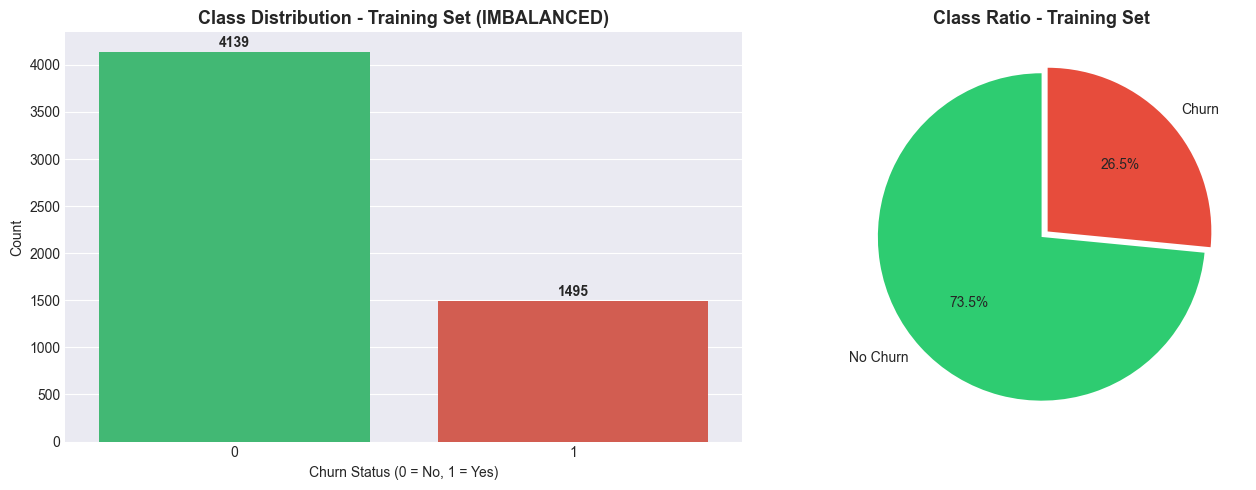

In [13]:

print("          BASELINE MODEL (Imbalanced Data)")
print()

# Check class distribution (Statistical Evidence of Imbalance)
print("\n Class Distribution in Training Set (BEFORE balancing):")
print()
class_counts = y_train.value_counts()
class_ratios = y_train.value_counts(normalize=True) * 100
print()
print()
print(f"   Absolute Counts:\n{class_counts}")
print(f"\n   Normalized Ratios (%):\n{class_ratios.round(2)}")

# Visualize imbalance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x=y_train, ax=ax1, palette=['#2ecc71', '#e74c3c'])
ax1.set_title('Class Distribution - Training Set (IMBALANCED)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Churn Status (0 = No, 1 = Yes)')
ax1.set_ylabel('Count')
for i, count in enumerate(class_counts):
    ax1.text(i, count + 50, str(count), ha='center', fontweight='bold')

# Pie chart
ax2.pie(class_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.05))
ax2.set_title('Class Ratio - Training Set', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [14]:

# Train baseline Random Forest
baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Performance metrics
print("BASELINE MODEL PERFORMANCE (Imbalanced)")
print()
print("\n Note: Low Recall for Churn=1 is expected due to class imbalance.")
print()
print(classification_report(y_test, y_pred_baseline, target_names=['No Churn', 'Churn']))

# Store baseline metrics for comparison
baseline_recall = recall_score(y_test, y_pred_baseline, pos_label=1)
baseline_precision = precision_score(y_test, y_pred_baseline, pos_label=1)
baseline_f1 = f1_score(y_test, y_pred_baseline, pos_label=1)

print(f"\n Baseline Summary for Churn Class (1):")
print()
print(f"   • Recall:    {baseline_recall:.3f} (detects {baseline_recall*100:.1f}% of churners)")
print(f"   • Precision: {baseline_precision:.3f}")
print(f"   • F1-Score:  {baseline_f1:.3f}")

BASELINE MODEL PERFORMANCE (Imbalanced)


 Note: Low Recall for Churn=1 is expected due to class imbalance.

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


 Baseline Summary for Churn Class (1):

   • Recall:    0.497 (detects 49.7% of churners)
   • Precision: 0.637
   • F1-Score:  0.559


 SMOTETomek + Optimized Random Forest


PART 2: HANDLING IMBALANCE WITH SMOTETomek


 Applying SMOTETomek to training data...
   Training size BEFORE: 5634 samples
   Training size AFTER:  7512 samples



 Class Distribution AFTER SMOTETomek:
   Absolute Counts:
Churn
0    3756
1    3756
Name: count, dtype: int64

   Normalized Ratios (%):
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


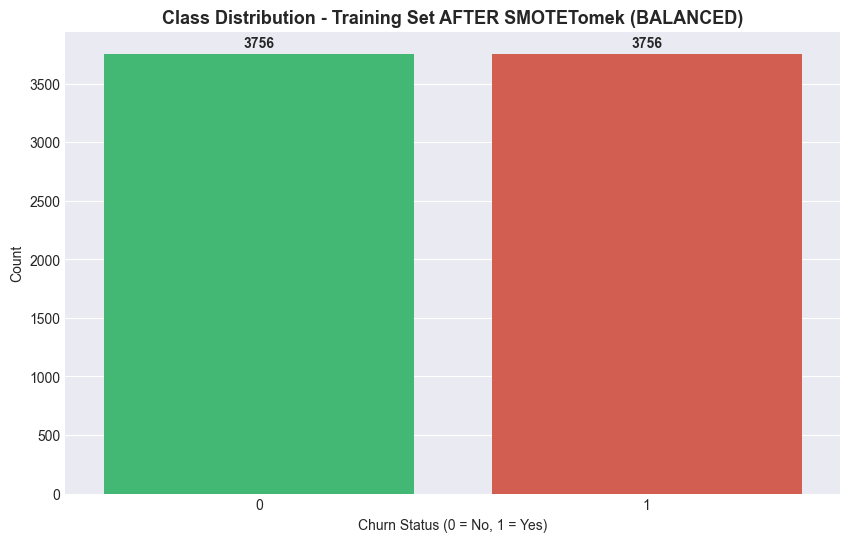

In [15]:

print()
print("PART 2: HANDLING IMBALANCE WITH SMOTETomek")
print()

# Apply SMOTETomek (Advanced oversampling + cleaning)
print("\n Applying SMOTETomek to training data...")

smote_tomek = SMOTETomek(random_state=42)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)


print(f"   Training size BEFORE: {len(y_train)} samples")
print(f"   Training size AFTER:  {len(y_train_res)} samples")
print()
print()
# Verify balance
print("\n Class Distribution AFTER SMOTETomek:")
balanced_counts = y_train_res.value_counts()
balanced_ratios = y_train_res.value_counts(normalize=True) * 100
print(f"   Absolute Counts:\n{balanced_counts}")
print(f"\n   Normalized Ratios (%):\n{balanced_ratios.round(2)}")

# Visualize balanced data
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x=y_train_res, ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution - Training Set AFTER SMOTETomek (BALANCED)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Status (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
for i, count in enumerate(balanced_counts):
    ax.text(i, count + 50, str(count), ha='center', fontweight='bold')
plt.show()


In [16]:

print("PART 3: TRAINING OPTIMIZED RANDOM FOREST")
print()
print("\n  Optimized Hyperparameters:")


# Train optimized model on balanced data
optimized_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\n Training optimized model on balanced data...")
optimized_model.fit(X_train_res, y_train_res)

# Get prediction probabilities (for threshold tuning)
y_proba = optimized_model.predict_proba(X_test)[:, 1]

# Default predictions (threshold = 0.5)
y_pred_default = optimized_model.predict(X_test)
print()
print()
print("MODEL PERFORMANCE (After SMOTETomek, Threshold = 0.50)")
print()
print(classification_report(y_test, y_pred_default, target_names=['No Churn', 'Churn']))

PART 3: TRAINING OPTIMIZED RANDOM FOREST


  Optimized Hyperparameters:

 Training optimized model on balanced data...


MODEL PERFORMANCE (After SMOTETomek, Threshold = 0.50)

              precision    recall  f1-score   support

    No Churn       0.88      0.81      0.84      1035
       Churn       0.57      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



Threshold Optimization + Final Evaluation

In [17]:

print()
print("PART 4: THRESHOLD OPTIMIZATION")
print()
print()

print("\n  Testing different decision thresholds...")
print("-"*65)
print(f"{'Threshold':<15} {'Recall':<15} {'Precision':<15} {'F1-Score':<15}")
print("-"*65)

# Test multiple thresholds
results = []
thresholds = np.arange(0.25, 0.51, 0.05)

for thresh in thresholds:
    y_pred_tuned = (y_proba >= thresh).astype(int)
    rec = recall_score(y_test, y_pred_tuned, pos_label=1)
    prec = precision_score(y_test, y_pred_tuned, pos_label=1)
    f1 = f1_score(y_test, y_pred_tuned, pos_label=1)
    
    results.append({
        'threshold': thresh,
        'recall': rec,
        'precision': prec,
        'f1': f1
    })
    
    print(f"{thresh:<15.2f} {rec:<15.3f} {prec:<15.3f} {f1:<15.3f}")

# Select best threshold (prioritize Recall while keeping Precision >= 0.50)
best_result = None
best_score = 0

for res in results:
    if res['precision'] >= 0.50:
        if res['recall'] > best_score:
            best_score = res['recall']
            best_result = res

# Fallback: choose best F1 if no threshold meets precision criteria
if best_result is None:
    best_result = max(results, key=lambda x: x['f1'])

best_threshold = best_result['threshold']
print()
print()
print(f"\n OPTIMAL THRESHOLD SELECTED   : {best_threshold:.2f}")
print(f"   → Recall:    {best_result['recall']:.3f} ({best_result['recall']*100:.1f}% of churners detected)")
print(f"   → Precision: {best_result['precision']:.3f}")
print(f"   → F1-Score:  {best_result['f1']:.3f}")

# Final predictions with optimal threshold
y_pred_final = (y_proba >= best_threshold).astype(int)



PART 4: THRESHOLD OPTIMIZATION



  Testing different decision thresholds...
-----------------------------------------------------------------
Threshold       Recall          Precision       F1-Score       
-----------------------------------------------------------------
0.25            0.856           0.462           0.600          
0.30            0.824           0.487           0.612          
0.35            0.791           0.509           0.620          
0.40            0.765           0.530           0.626          
0.45            0.749           0.552           0.636          
0.50            0.706           0.571           0.632          



 OPTIMAL THRESHOLD SELECTED   : 0.35
   → Recall:    0.791 (79.1% of churners detected)
   → Precision: 0.509
   → F1-Score:  0.620


FINAL MODEL PERFORMANCE (Threshold = 0.35)

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



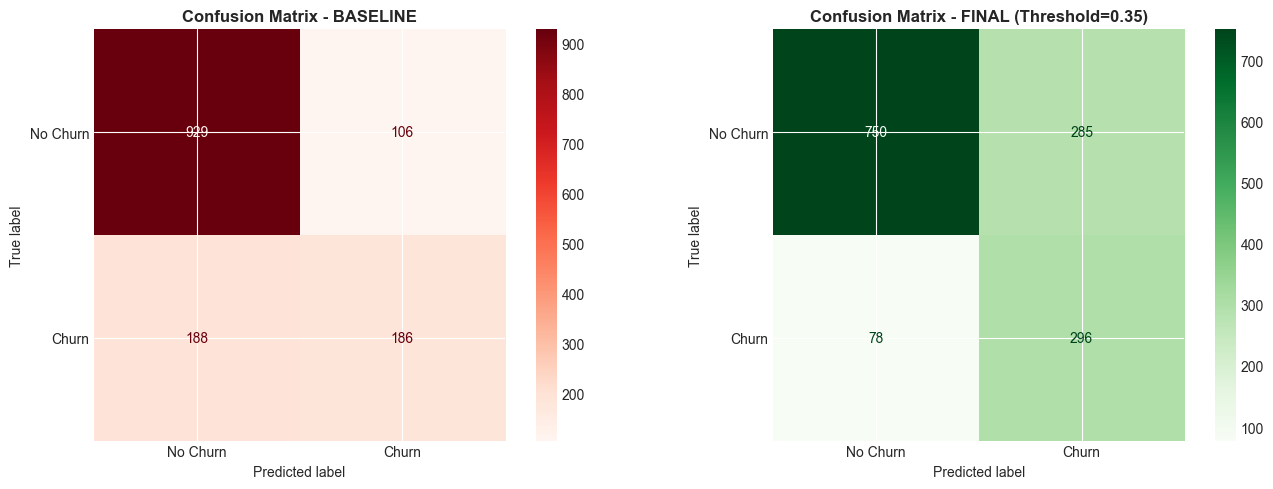

In [18]:

print(f"FINAL MODEL PERFORMANCE (Threshold = {best_threshold:.2f})")
print()
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))

# Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, 
    display_labels=['No Churn', 'Churn'],
    ax=axes[0], cmap='Reds'
)
axes[0].set_title('Confusion Matrix - BASELINE', fontsize=12, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['No Churn', 'Churn'],
    ax=axes[1], cmap='Greens'
)
axes[1].set_title(f'Confusion Matrix - FINAL (Threshold={best_threshold:.2f})', 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [19]:


print("FINAL COMPARISON SUMMARY")
print()

final_recall = recall_score(y_test, y_pred_final, pos_label=1)
final_precision = precision_score(y_test, y_pred_final, pos_label=1)
final_f1 = f1_score(y_test, y_pred_final, pos_label=1)

recall_improvement = ((final_recall - baseline_recall) / baseline_recall) * 100
f1_improvement = ((final_f1 - baseline_f1) / baseline_f1) * 100

comparison_data = {
    'Metric': ['Recall (Churn=1)', 'Precision (Churn=1)', 'F1-Score (Churn=1)'],
    'Baseline': [f"{baseline_recall:.3f}", f"{baseline_precision:.3f}", f"{baseline_f1:.3f}"],
    'Final': [f"{final_recall:.3f}", f"{final_precision:.3f}", f"{final_f1:.3f}"],
    'Improvement': [f"+{recall_improvement:.1f}%", 
                    f"{(final_precision-baseline_precision)/baseline_precision*100:+.1f}%",
                    f"+{f1_improvement:.1f}%"]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))


print("\n KEY FINDINGS:")
print(f"    Recall improved from {baseline_recall:.1%} to {final_recall:.1%}")
print(f"    {recall_improvement:.1f}% increase in detecting potential churners")
print(f"    Techniques applied: SMOTETomek + Hyperparameter Tuning + Threshold Optimization")
print(f"    Optimal threshold selected: {best_threshold:.2f}")

print("\n BUSINESS IMPACT:")
print(f"   • Model now identifies {final_recall*100:.1f}% of customers at risk of churning")
print(f"   • {final_precision*100:.1f}% of churn alerts are accurate")
print(f"   • Enables more effective proactive retention strategies")

FINAL COMPARISON SUMMARY


             Metric Baseline Final Improvement
   Recall (Churn=1)    0.497 0.791      +59.1%
Precision (Churn=1)    0.637 0.509      -20.0%
 F1-Score (Churn=1)    0.559 0.620      +11.0%

 KEY FINDINGS:
    Recall improved from 49.7% to 79.1%
    59.1% increase in detecting potential churners
    Techniques applied: SMOTETomek + Hyperparameter Tuning + Threshold Optimization
    Optimal threshold selected: 0.35

 BUSINESS IMPACT:
   • Model now identifies 79.1% of customers at risk of churning
   • 50.9% of churn alerts are accurate
   • Enables more effective proactive retention strategies


#  DATA VISUALIZATION

In [29]:
# ==========================================
# SIMPLE DATA VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

# Prepare data
pro_df_viz = pro_df.copy()
pro_df_viz['Churn_Text'] = pro_df_viz['Churn'].map({1: 'Yes', 0: 'No'})

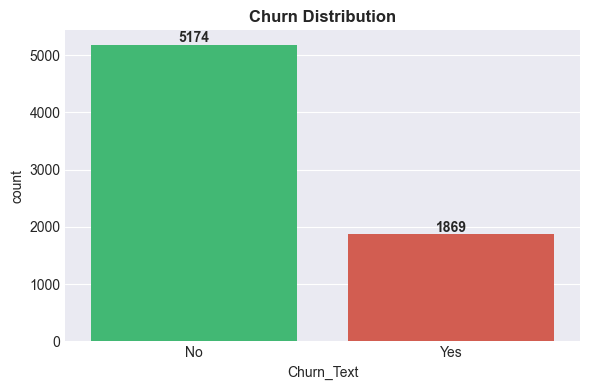

In [30]:
# ==========================================
# 1. Churn Distribution
# ==========================================
plt.figure(figsize=(6, 4))

sns.countplot(
    data=pro_df_viz,
    x='Churn_Text',
    palette=['#2ecc71', '#e74c3c']
)

plt.title('Churn Distribution', fontweight='bold')

for i, count in enumerate(pro_df_viz['Churn_Text'].value_counts()):
    plt.text(i, count + 50, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

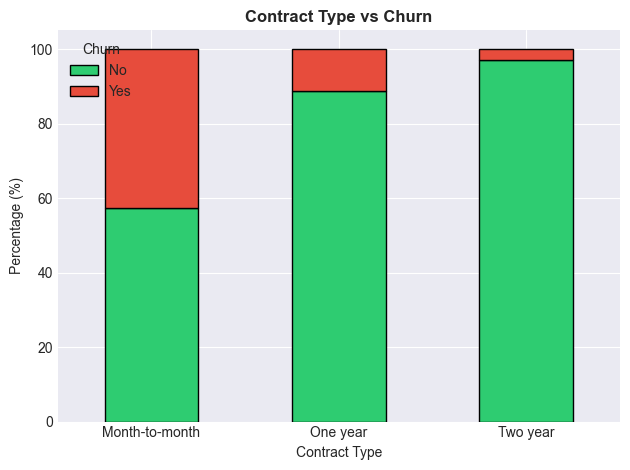

In [31]:

# ==========================================
# 2. Contract Type vs Churn
# ==========================================
plt.figure(figsize=(8, 5))

contract_churn = pd.crosstab(
    pro_df_viz['Contract'],
    pro_df_viz['Churn_Text'],
    normalize='index'
) * 100

contract_churn.plot(
    kind='bar',
    stacked=True,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)

plt.title('Contract Type vs Churn', fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


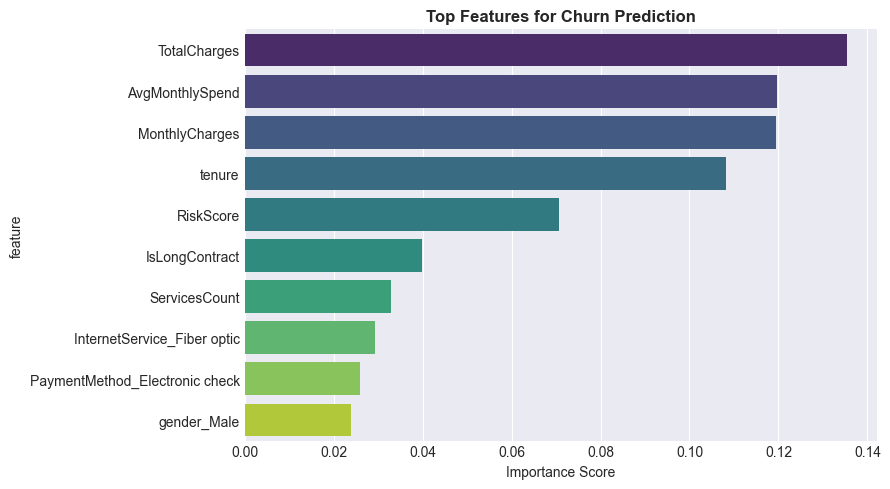

In [ ]:



# ==========================================
# 3. Top Features Importance
# ==========================================
if 'rf' in dir() and hasattr(rf, 'feature_importances_'):

    feature_importance = pd.DataFrame({
        'feature': X_encoded.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    plt.figure(figsize=(9, 5))

    sns.barplot(
        
        data=feature_importance,
        y='feature',
        x='importance',
        palette='viridis'
    )

    plt.title('Top Features for Churn Prediction', fontweight='bold')
    plt.xlabel('Importance Score')

    plt.tight_layout()
    plt.show()